In [16]:
股票代码 = '600000'

In [17]:
import akshare as ak
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

In [18]:
df_p = ak.stock_zh_a_hist(symbol=股票代码,period="daily",start_date="20240306",end_date='20250306',adjust='')

In [19]:
df_p

,日期,股票代码,开盘,收盘,最高,最低,成交量,成交额,振幅,涨跌幅,涨跌额,换手率
0,2024-03-06,600000,7.17,7.12,7.22,7.12,259187,185847810.0,1.40,-0.56,-0.04,0.09
1,2024-03-07,600000,7.12,7.14,7.20,7.11,246903,176664369.0,1.26,0.28,0.02,0.08
2,2024-03-08,600000,7.12,7.12,7.17,7.11,198618,141724066.0,0.84,-0.28,-0.02,0.07
3,2024-03-11,600000,7.13,7.11,7.17,7.06,261955,185957986.0,1.54,-0.14,-0.01,0.09
4,2024-03-12,600000,7.11,7.10,7.15,7.08,290305,206425806.0,0.98,-0.14,-0.01,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...
237,2025-02-28,600000,10.23,10.17,10.30,10.17,446511,457102788.0,1.27,-0.68,-0.07,0.15
238,2025-03-03,600000,10.19,10.15,10.22,10.08,430109,436849850.0,1.38,-0.20,-0.02,0.15
239,2025-03-04,600000,10.10,10.10,10.19,10.10,297698,301634439.0,0.89,-0.49,-0.05,0.10
240,2025-03-05,600000,10.14,10.25,10.26,10.05,416864,424730036.0,2.08,1.49,0.15,0.14


In [20]:
df = pd.DataFrame(df_p)

In [21]:
df.set_index('日期', inplace=True)

In [22]:
df['SMA_12'] = df['收盘'].rolling(12).mean()
df['SMA_26'] = df['收盘'].rolling(26).mean()

<Axes: title={'center': ' SMAs'}, xlabel='日期'>

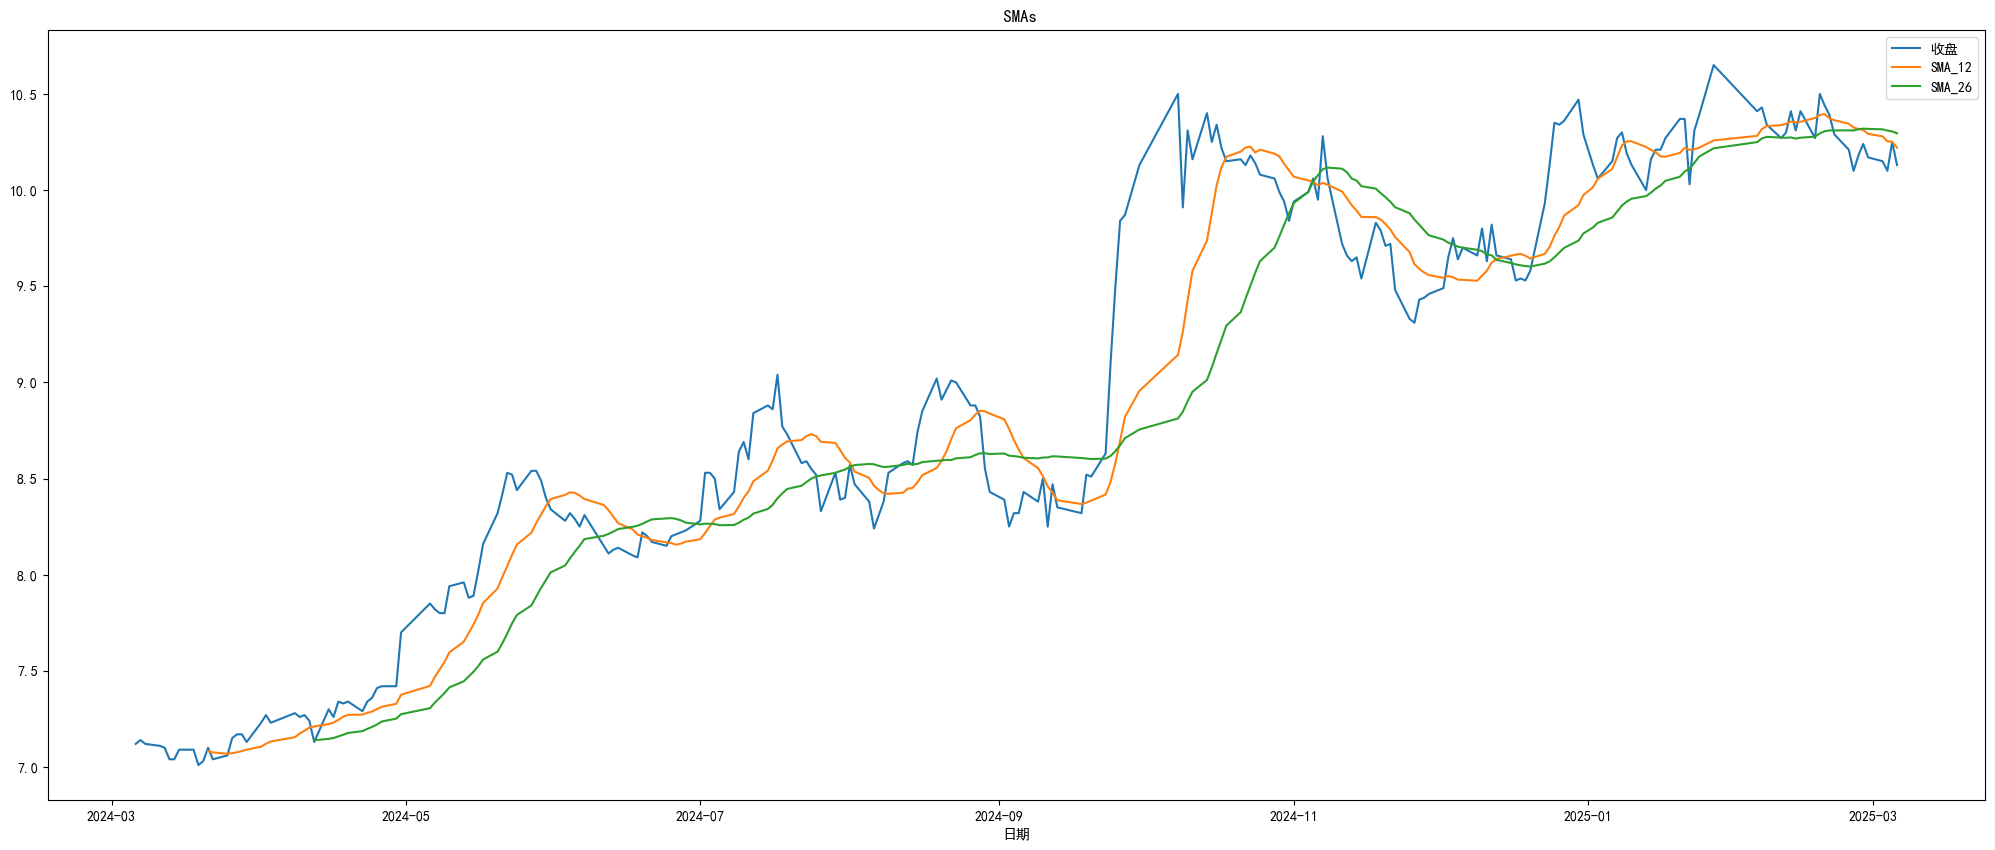

In [23]:
plt.rcParams['font.sans-serif'] = ['SimHei']
df[['收盘','SMA_12','SMA_26']].plot(title=' SMAs',figsize=(25, 10))

In [ ]:
df['position']= np.where(df['SMA_12']>df['SMA_26'],1,-1)
df.dropna(inplace=True)
df.head() 

df['position'] = np.where(
    df['成交量'] > 0.5,
    1,
    np.where(
        df['ewma_trend'] < -EWMA_threshold,-1,
        0
    )
)
train.dropna(inplace=True)

,股票代码,开盘,收盘,最高,最低,成交量,成交额,振幅,涨跌幅,涨跌额,换手率,SMA_12,SMA_26,position
日期,,,,,,,,,,,,,,
2024-04-12,600000,7.20,7.13,7.26,7.12,328097,235493710.0,1.93,-1.52,-0.11,0.11,7.210833,7.139231,1
2024-04-15,600000,7.12,7.30,7.30,7.12,483103,350007626.0,2.52,2.38,0.17,0.16,7.223333,7.146154,1
2024-04-16,600000,7.25,7.26,7.32,7.21,402033,292494126.0,1.51,-0.55,-0.04,0.14,7.230833,7.150769,1
2024-04-17,600000,7.26,7.34,7.35,7.18,431519,314102077.0,2.34,1.10,0.08,0.15,7.245000,7.159231,1
2024-04-18,600000,7.34,7.33,7.46,7.31,468225,345482146.0,2.04,-0.14,-0.01,0.16,7.261667,7.167692,1


<Axes: title={'center': 'Market Positioning'}, xlabel='日期'>

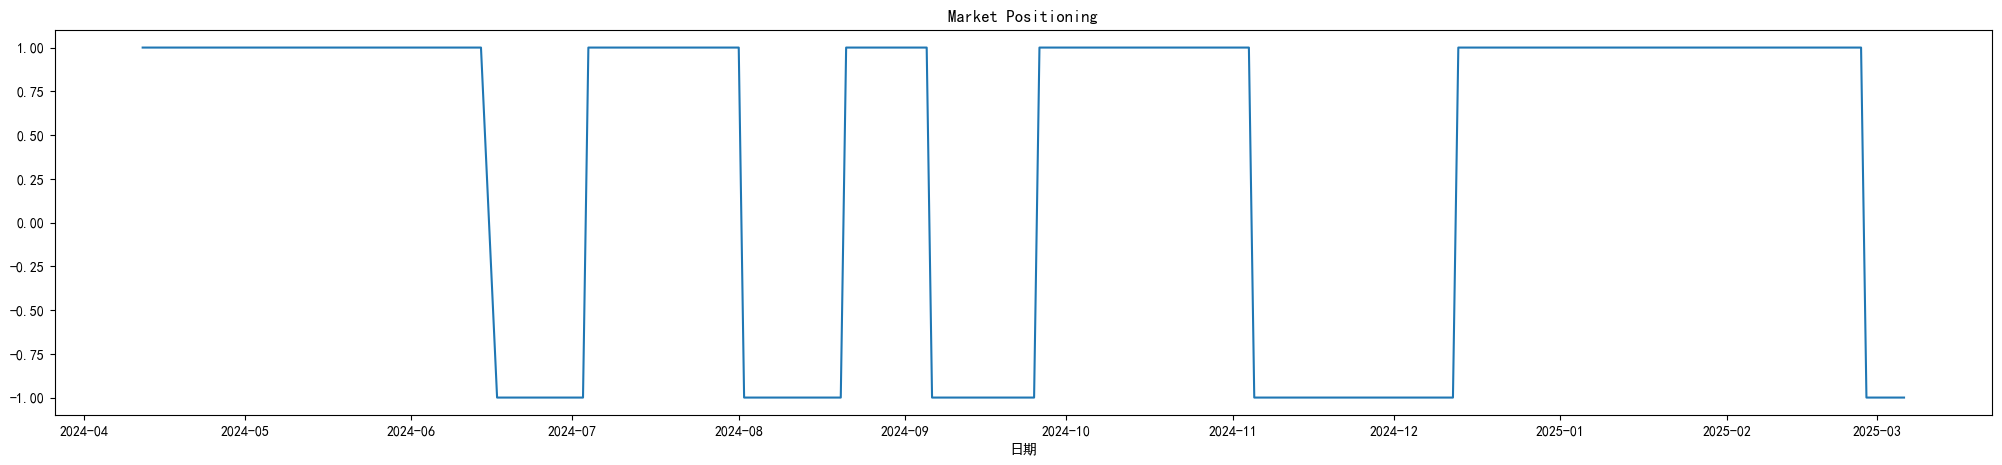

In [25]:
plt.rcParams['axes.unicode_minus'] = False # 显示负号
df['position'].plot(ylim=[-1.1,1.1],figsize=(25,5),title='Market Positioning')

In [26]:
buy = df[df['position'] == 1]
sell = df[df['position'] == -1]

In [37]:
sell['成交量'].mean()

444324.05555555556

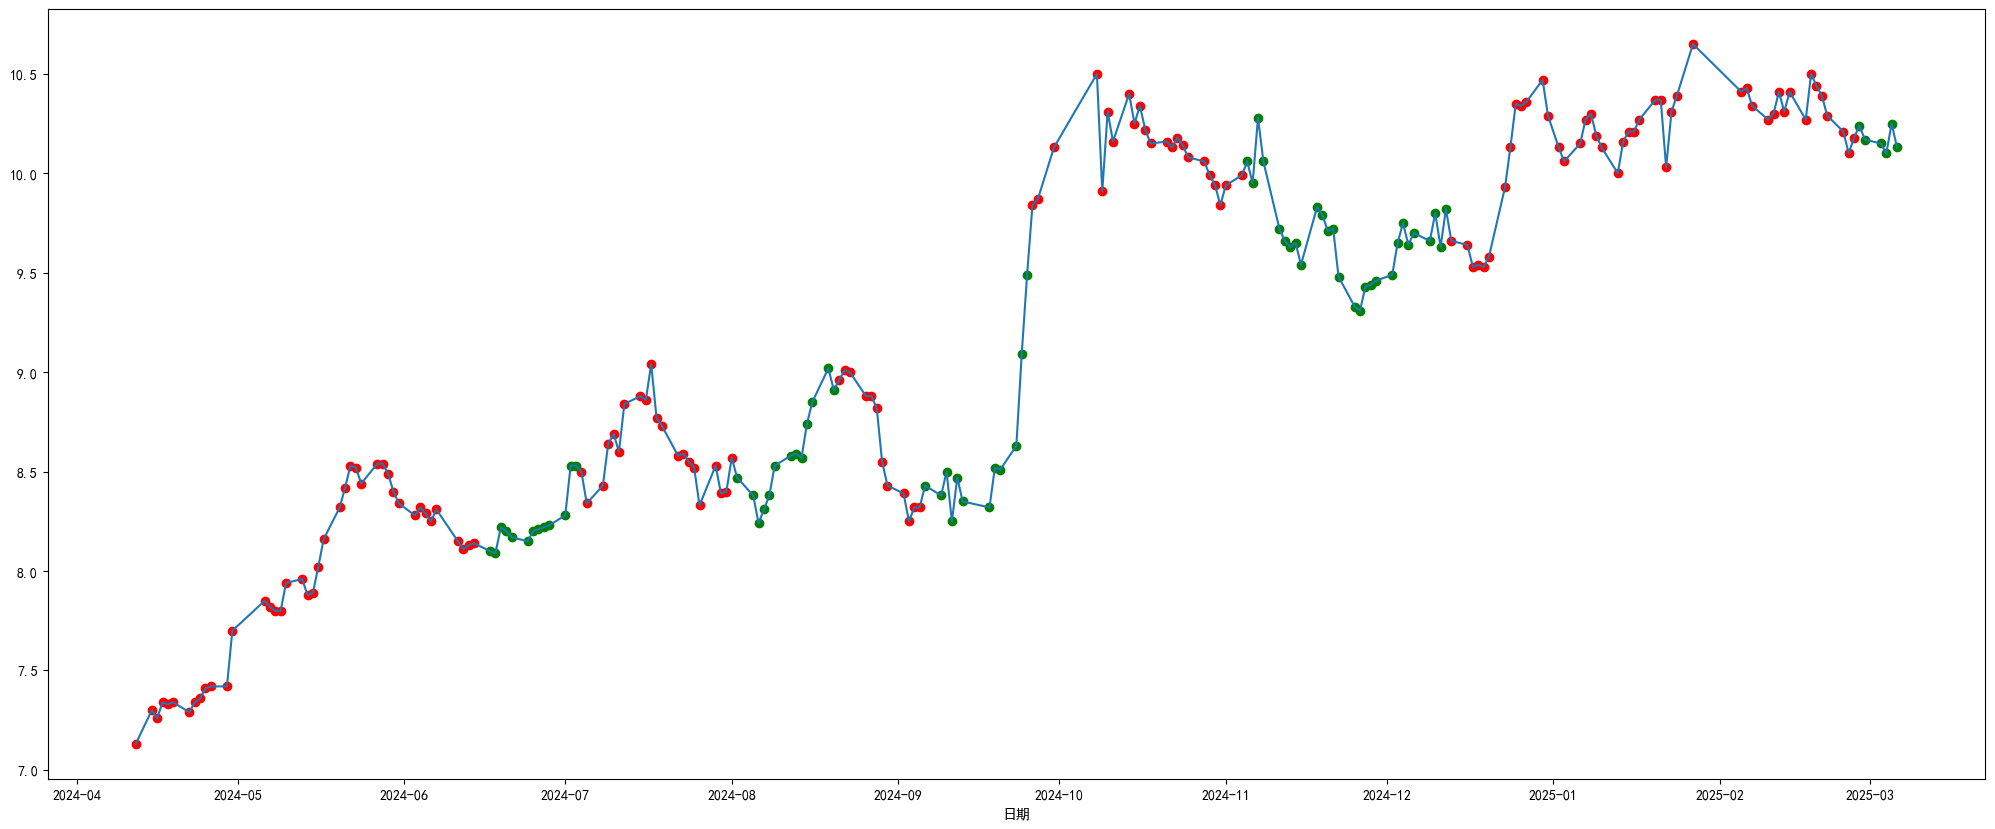

In [27]:
df['收盘'].plot(figsize=(25, 10))
plt.scatter(buy.index, buy['收盘'],color='red')
plt.scatter(sell.index, sell['收盘'],color='green')

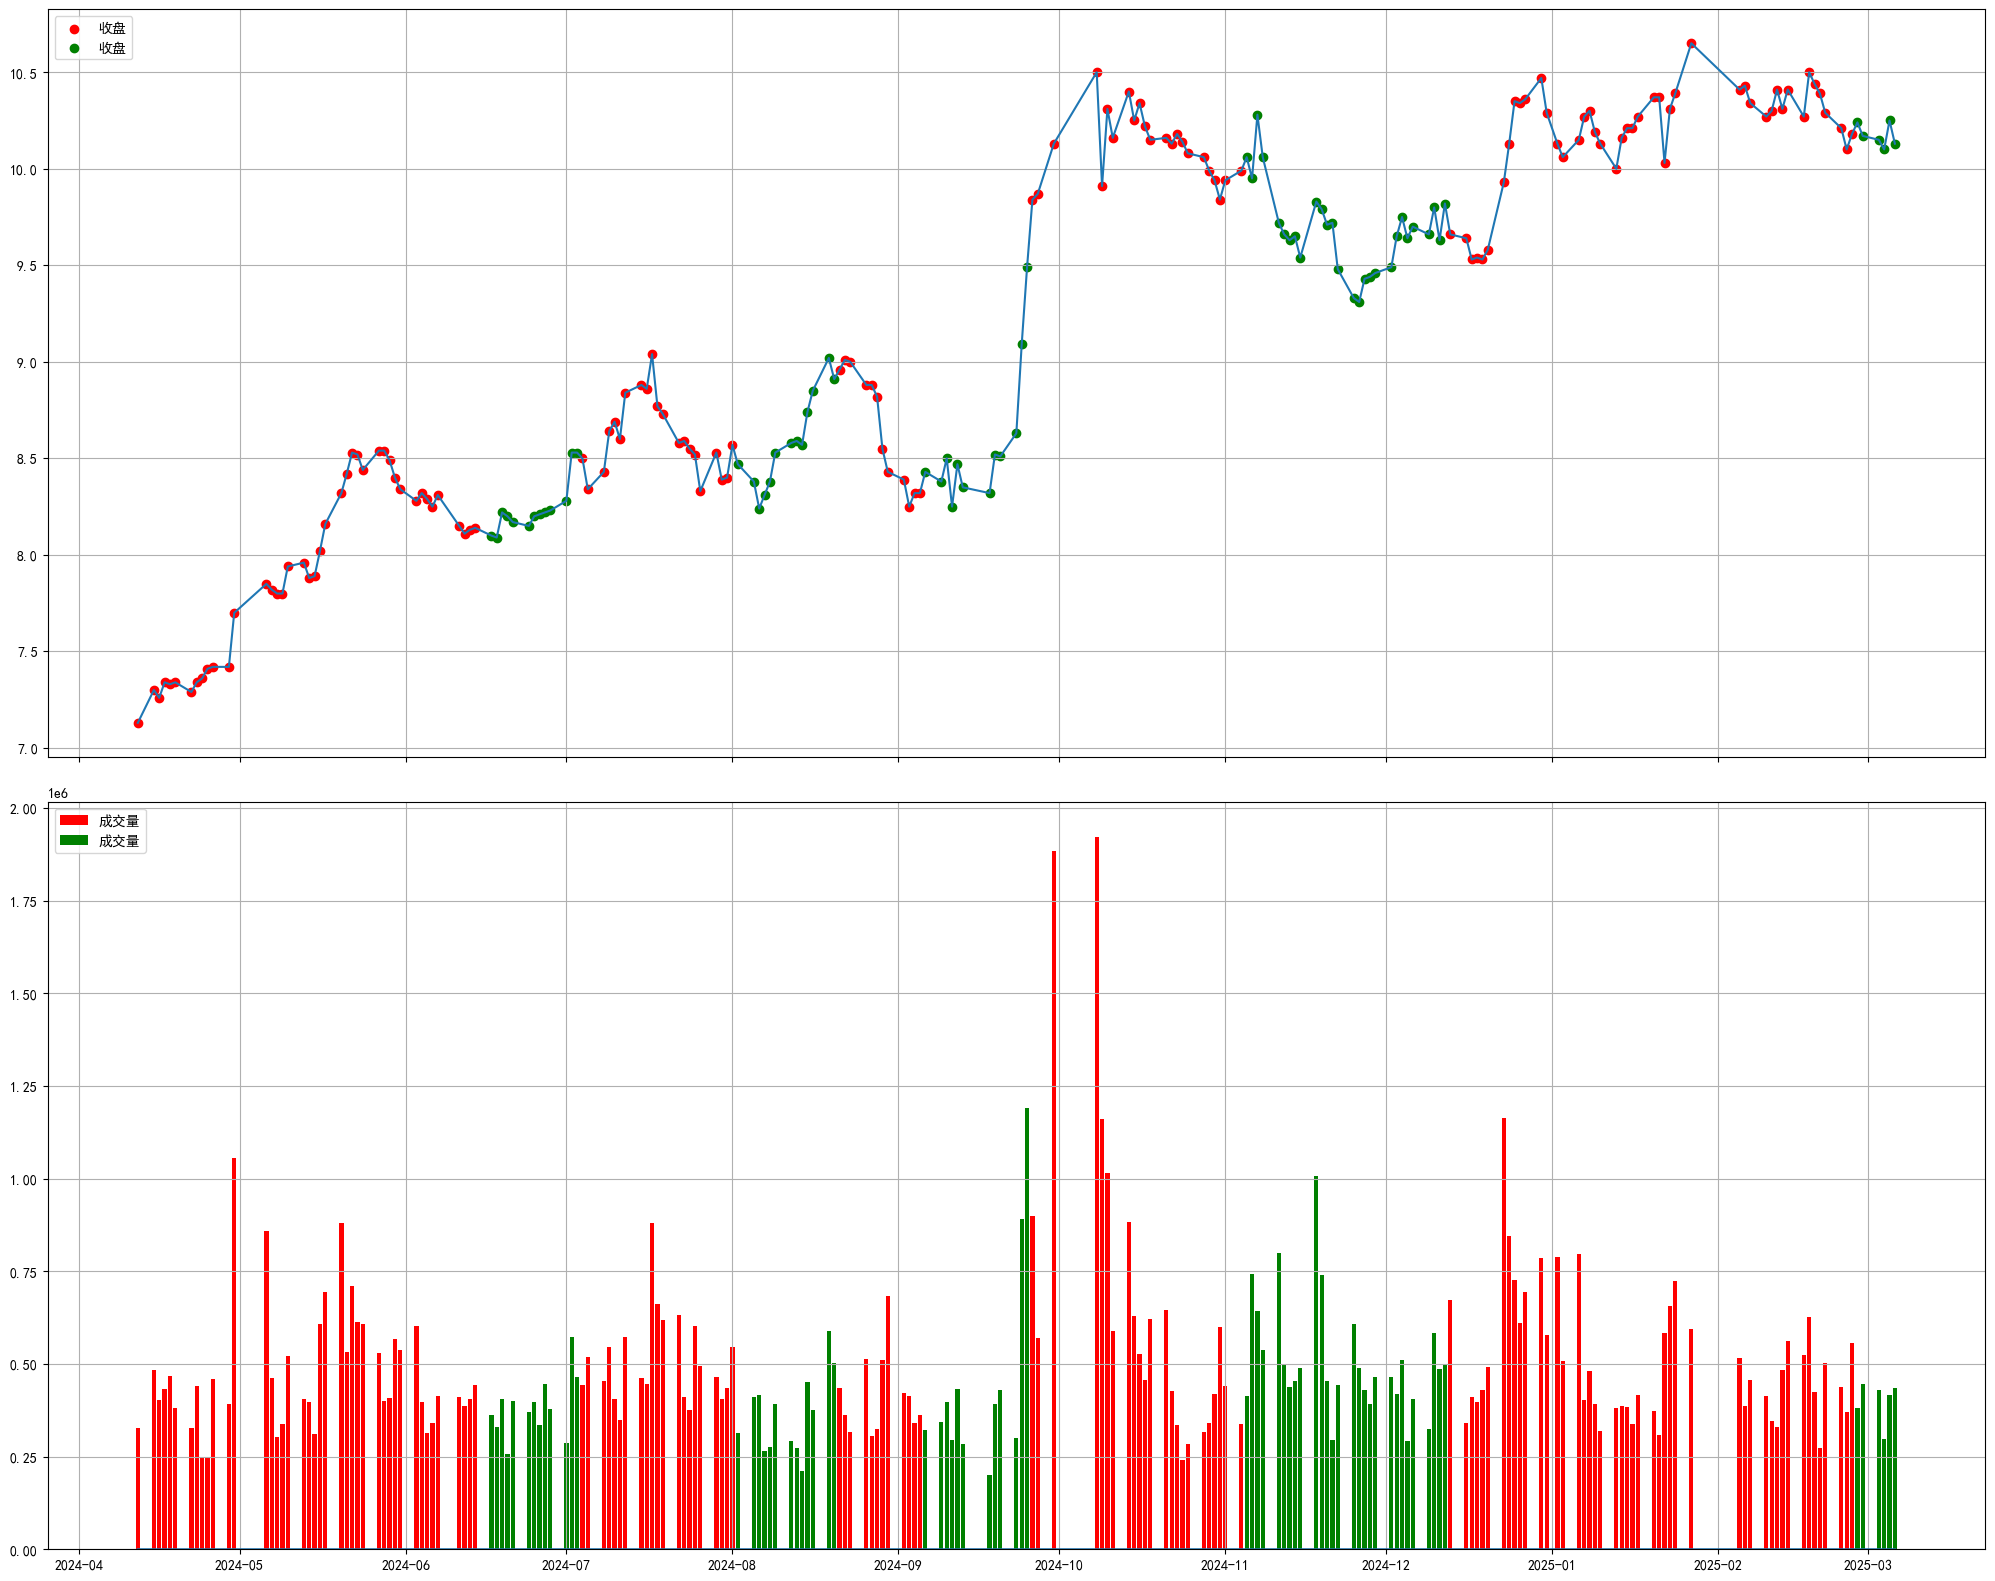

In [28]:
fig, (ax1,ax2) = plt.subplots(2, 1, sharex=True, figsize=(25,20))

ax1.plot(df['收盘'])
ax1.scatter(buy.index, buy['收盘'], color='red', label='收盘')
ax1.scatter(sell.index, sell['收盘'], color='green', label='收盘')
ax1.set_label('收盘')
ax1.legend(loc='upper left')
ax1.grid(True)

ax2.plot(df['收盘'])
ax2.bar(buy.index, buy['成交量'], color='red', label='成交量')
ax2.bar(sell.index, sell['成交量'], color='green', label='成交量')
ax2.set_label('成交量')
ax2.legend(loc='upper left')
ax2.grid(True)

plt.subplots_adjust(hspace=0.06)

In [29]:
df['strategy'] = df['position'].shift(1) * df['涨跌额']
df[['涨跌额','strategy']].sum()

涨跌额         2.89
strategy   -0.58
dtype: float64

<Axes: xlabel='日期'>

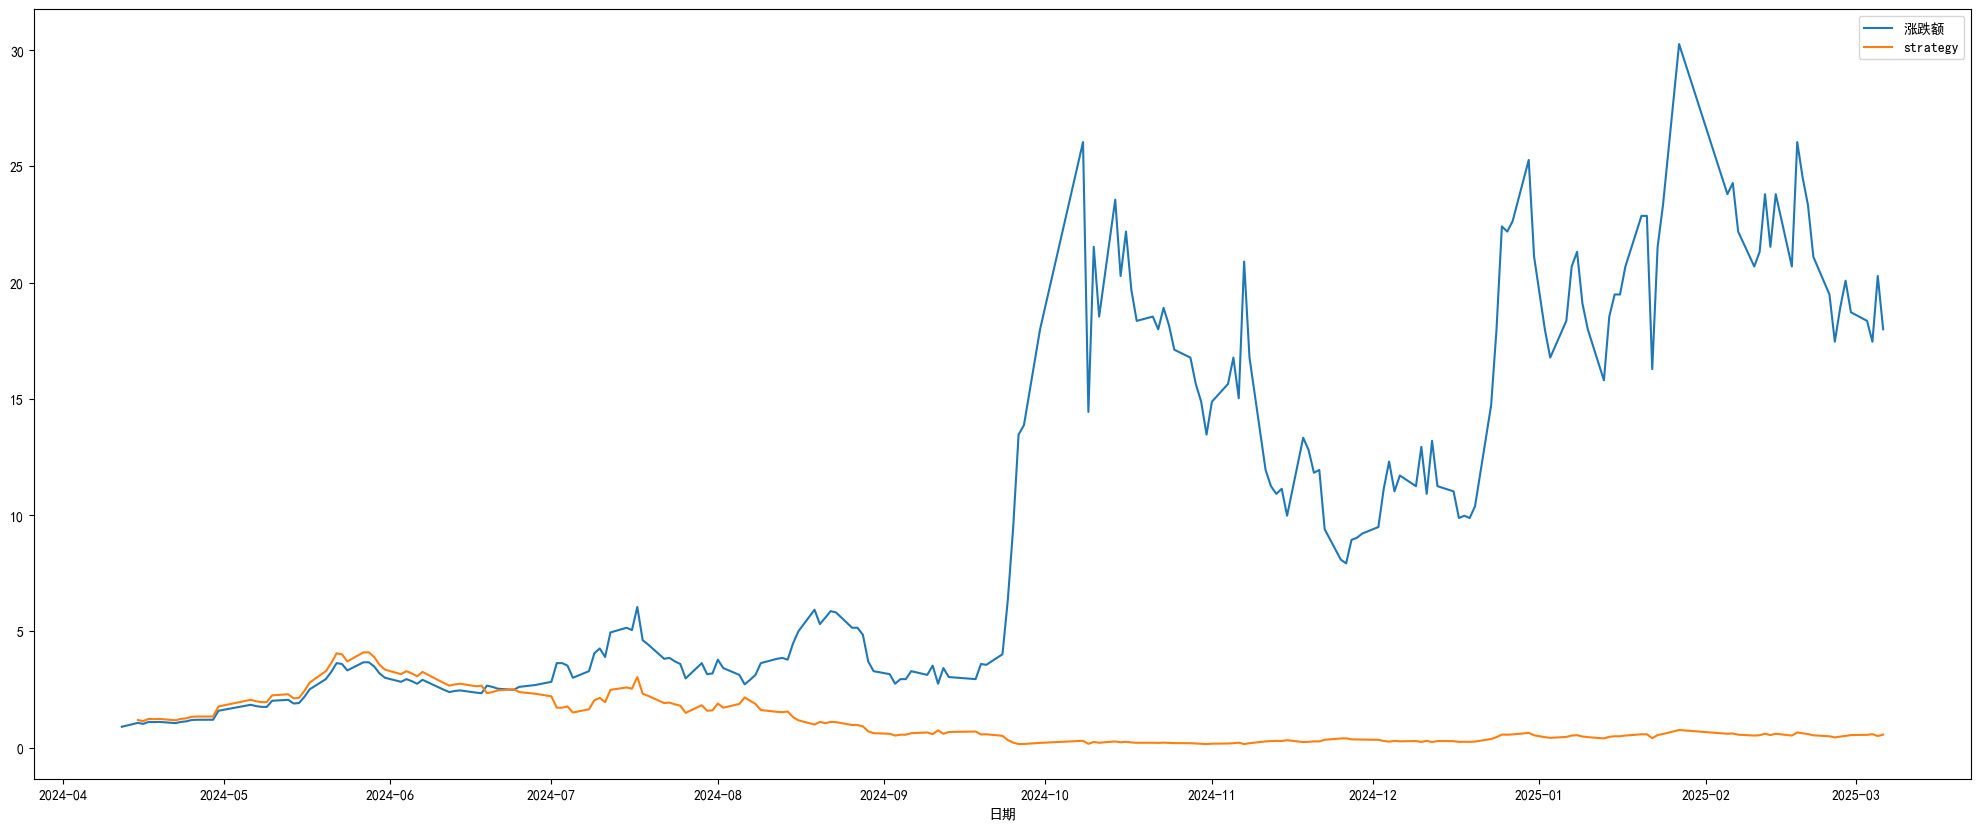

In [30]:
df[['涨跌额','strategy']].cumsum().apply(np.exp).plot(figsize=(25,10))

In [31]:
df[['涨跌额','strategy']].mean()

涨跌额         0.013318
strategy   -0.002685
dtype: float64

In [32]:
df[['涨跌额','strategy']].std()

涨跌额         0.140509
strategy    0.141244
dtype: float64

In [33]:
df[['涨跌额','strategy']].mean()/df[['涨跌额','strategy']].std()

涨跌额         0.094784
strategy   -0.019011
dtype: float64

<Axes: xlabel='日期'>

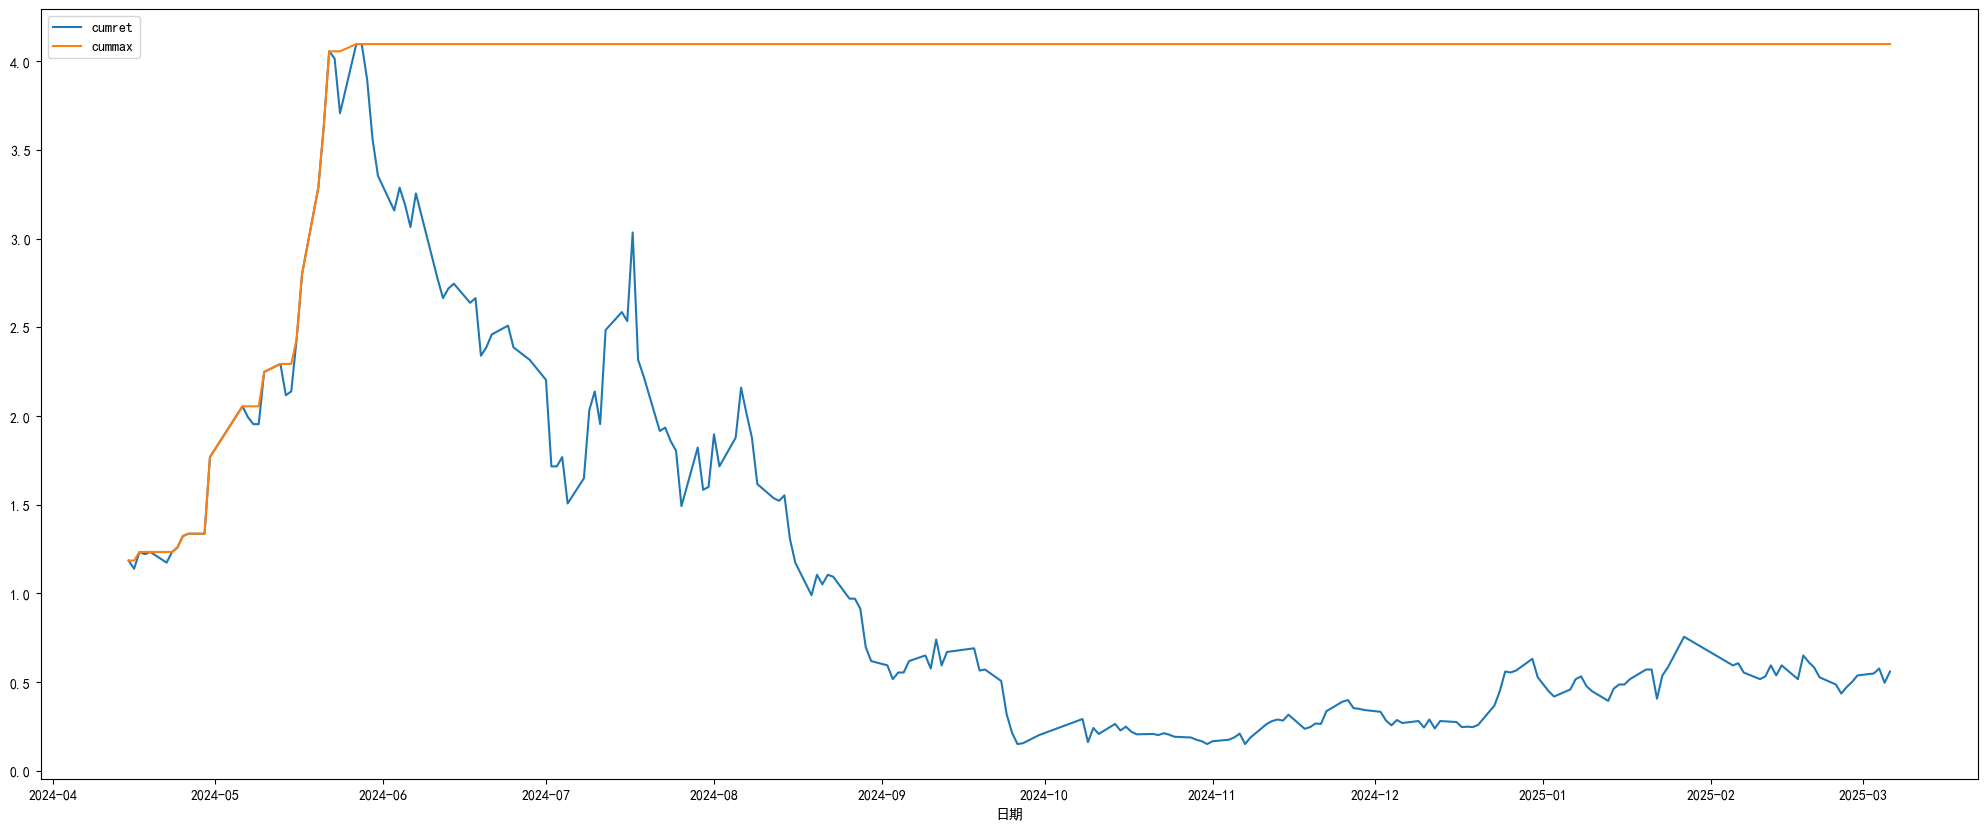

In [34]:
df['cumret'] = df['strategy'].cumsum().apply(np.exp)
df['cummax']= df['cumret'].cummax()
df[['cumret','cummax']].plot(figsize=(25,10))

In [35]:
traindrawdown = (df['cummax'] - df['cumret'])
traindrawdown.max()

3.9448835952348067